Good matches: 1263
Inlier matches: 1238
Rotation:
 [[ 0.99997009  0.00470519 -0.00613906]
 [-0.00471964  0.99998612 -0.00234138]
 [ 0.00612796  0.00237029  0.99997841]]
Translation:
 [[-0.39328787]
 [-0.03565386]
 [ 0.91872382]]
Valid 3D points: 815


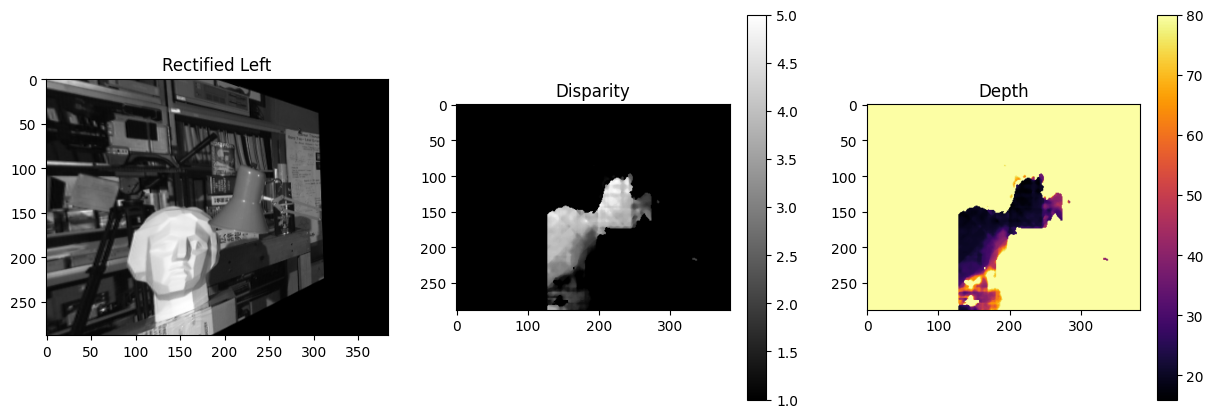

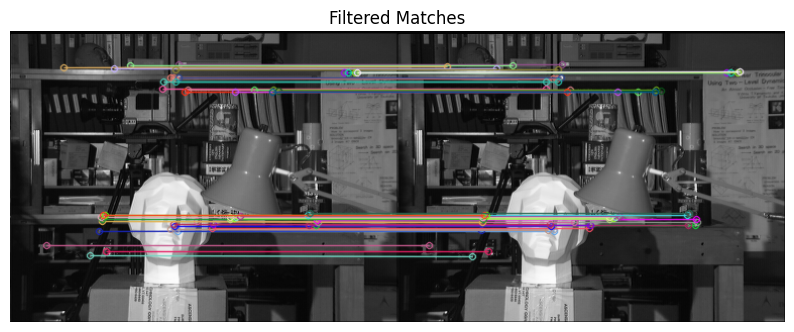

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imgL = cv2.imread(r'E:\Computer Vision\LAB\lab09\tsukuba_l.png')
imgR = cv2.imread(r'E:\Computer Vision\LAB\lab09\tsukuba_r.png')

grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

h, w = grayL.shape
orb = cv2.ORB_create(4000)

kp1, des1 = orb.detectAndCompute(grayL, None)
kp2, des2 = orb.detectAndCompute(grayR, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Good matches:", len(good))

pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

print("Inlier matches:", len(pts1))

fx = fy = 800
cx = w / 2
cy = h / 2

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])

E = K.T @ F @ K
_, R, t, _ = cv2.recoverPose(E, pts1, pts2, K)

print("Rotation:\n", R)
print("Translation:\n", t)

retval, H1, H2 = cv2.stereoRectifyUncalibrated(
    pts1, pts2, F, (w, h)
)

rectL = cv2.warpPerspective(grayL, H1, (w, h))
rectR = cv2.warpPerspective(grayR, H2, (w, h))

min_disp = 0
num_disp = 128 

stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=7,
    P1=8 * 3 * 7**2,
    P2=32 * 3 * 7**2,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=50,
    speckleRange=2
)

disparity = stereo.compute(rectL, rectR).astype(np.float32) / 16.0

disparity[disparity < 1] = 1

baseline = 0.1

depth = (fx * baseline) / disparity
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = K @ np.hstack((R, t))

pts1_T = pts1.T
pts2_T = pts2.T

points_4D = cv2.triangulatePoints(P1, P2, pts1_T, pts2_T)
points_3D = points_4D / points_4D[3]

points_3D = points_3D[:3].T

points_3D = points_3D[points_3D[:, 2] > 0]

print("Valid 3D points:", len(points_3D))
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Rectified Left")
plt.imshow(rectL, cmap='gray')

plt.subplot(1,3,2)
plt.title("Disparity")
plt.imshow(disparity, cmap='gray')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Depth")
plt.imshow(depth, cmap='inferno')
plt.colorbar()

plt.show()

img_matches = cv2.drawMatches(
    imgL, kp1, imgR, kp2, good[:50], None, flags=2
)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Filtered Matches")
plt.axis('off')
plt.show()